# Assigned Project Report

Statistics collected from GitHub and the World of Code Python API.


## GitHub repository statistics

| project | stars | forks | last commit date |
| --- | --- | --- | --- |
| hectornieto/pyTSEB | 171 | 75 | 2026-09-24T09:24:19Z |
| e3nn/e3nn | 1287 | 188 | 2026-02-13T22:02:26Z |
| kosma/minmea | 967 | 301 | 2026-09-20T12:04:00Z |
| digantamisra98/Mish | 1298 | 128 | 2026-07-20T10:05:15Z |
| pekkosk/hotbit | 69 | 35 | 2025-01-23T07:48:59Z |
| metagenomics/denbi-nanopore-training | 21 | 12 | 2022-10-05T07:18:50Z |
| BNUCNL/dnnbrain | 47 | 29 | 2024-11-07T03:03:48Z |
| secure-compilation/different_traces | 2 | 0 | 2025-05-08T04:31:40Z |
| irods/irods | 482 | 146 | 2026-09-24T17:47:08Z |
| cgre-aachen/gempy | 1345 | 281 | 2026-09-12T08:51:54Z |


## World of Code statistics

| project | number of commits | number of authors | max time | min time |
| --- | --- | --- | --- | --- |
| BNUCNL/dnnbrain | 1299 | 38 | 2024-11-20 19:32:59+00:00 | 2019-07-01 06:55:03+00:00 |
| cgre-aachen/gempy | 4153 | 100 | 2025-11-05 16:14:43+00:00 | 2017-07-04 12:35:48+00:00 |
| digantamisra98/Mish | 2994 | 10 | 2026-04-08 10:16:08+00:00 | 2019-05-10 14:05:19+00:00 |
| e3nn/e3nn | 4064 | 73 | 2025-10-14 10:55:47+00:00 | 2017-07-07 14:32:42+00:00 |
| hectornieto/pyTSEB | 435 | 21 | 2025-12-16 07:04:45+00:00 | 2016-01-14 15:39:36+00:00 |
| irods/irods | 17069 | 118 | 2025-11-05 01:16:52+00:00 | 2012-01-12 15:55:57+00:00 |
| kosma/minmea | 348 | 82 | 2025-11-03 12:33:43+00:00 | 2014-02-14 14:22:18+00:00 |
| metagenomics/denbi-nanopore-training | 878 | 8 | 2025-07-04 11:23:53+00:00 | 2017-11-07 11:43:29+00:00 |
| pekkosk/hotbit | 922 | 18 | 2025-03-11 17:52:32+00:00 | 2008-09-04 12:49:35+00:00 |
| secure-compilation/different_traces | 519 | 12 | 2025-05-08 04:31:40+00:00 | 2018-05-30 17:11:27+00:00 |


In [17]:
from pathlib import Path

import pandas as pd

source_path = Path(r"C:\Users\Ethan\Downloads\my_project\emolder_project_summary.csv")
output_path = source_path.with_name("emolder_commits_timeseries_.csv")

commits = pd.read_csv(source_path)
commit_months = pd.to_datetime(commits["time"], format="%m/%d/%Y").dt.to_period("M")
monthly_counts = commit_months.value_counts().sort_index()
all_months = pd.period_range(monthly_counts.index.min(), monthly_counts.index.max(), freq="M")

monthly_activity = pd.DataFrame(
    {
        "Month": all_months.astype(str),
        "#Commits": monthly_counts.reindex(all_months, fill_value=0).to_numpy(),
    }
)
monthly_activity.to_csv(output_path, index=False)

print(f"Saved {len(monthly_activity)} months to {output_path}")
monthly_activity

Saved 212 months to C:\Users\Ethan\Downloads\my_project\emolder_commits_timeseries_.csv


,Month,#Commits
0,2008-09,34
1,2008-10,64
2,2008-11,22
3,2008-12,16
4,2009-01,48
...,...,...
207,2025-12,3
208,2026-01,4
209,2026-02,6
210,2026-03,8


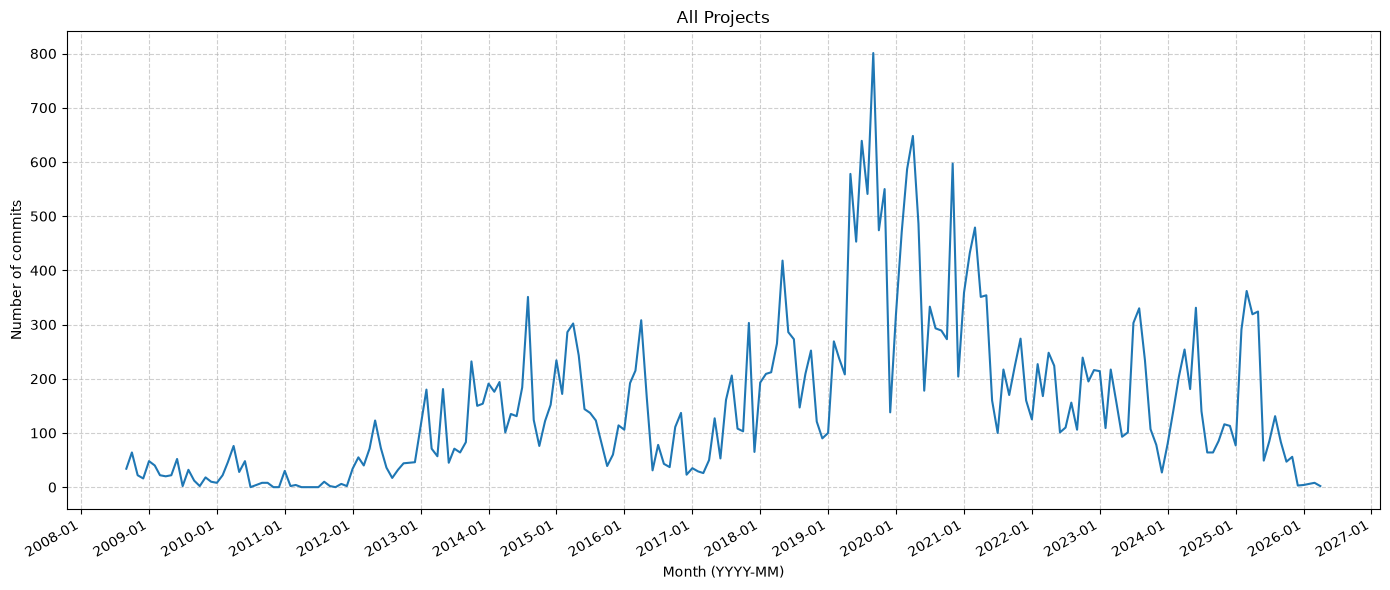

Saved plot to C:\Users\Ethan\Downloads\my_project\emolder_timeseries_all_projects.png at 300 DPI


In [18]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

monthly_path = Path(r"C:\Users\Ethan\Downloads\my_project\emolder_commits_timeseries_.csv")
source_path = monthly_path.with_name("emolder_project_summary.csv")
monthly_activity = pd.read_csv(monthly_path)
project_ids = pd.read_csv(source_path, usecols=["project_wocid"])["project_wocid"].dropna().unique()

project_id = project_ids[0] if len(project_ids) == 1 else "all_projects"
plot_title = project_ids[0] if len(project_ids) == 1 else "All Projects"
plot_path = monthly_path.with_name(f"emolder_timeseries_{project_id}.png")

months = pd.to_datetime(monthly_activity["Month"], format="%Y-%m")
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(months, monthly_activity["#Commits"], linewidth=1.5)
ax.set_title(plot_title)
ax.set_xlabel("Month (YYYY-MM)")
ax.set_ylabel("Number of commits")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, which="major", linestyle="--", alpha=0.6)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to {plot_path} at 300 DPI")

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd

folder = Path(r"C:\Users\Ethan\Downloads\my_project")
source_path = folder / "emolder_project_summary.csv"
stats_path = folder / "emolder_project_stats.csv"
commits = pd.read_csv(source_path)
commits["time"] = pd.to_datetime(commits["time"], format="%m/%d/%Y")

project_names = {
    "hectornieto_pytseb": "hectornieto/pyTSEB",
    "e3nn_e3nn": "e3nn/e3nn",
    "kosma_minmea": "kosma/minmea",
    "digantamisra98_mish": "digantamisra98/Mish",
    "pekkosk_hotbit": "pekkosk/hotbit",
    "metagenomics_denbi-nanopore-training": "metagenomics/denbi-nanopore-training",
    "bnucnl_dnnbrain": "BNUCNL/dnnbrain",
    "secure-compilation_different_traces": "secure-compilation/different_traces",
    "irods_irods": "irods/irods",
    "cgre-aachen_gempy": "cgre-aachen/gempy",
}

woc_stats = {
    "BNUCNL/dnnbrain": (1299, 38, "2024-11-20 19:32:59+00:00", "2019-07-01 06:55:03+00:00"),
    "cgre-aachen/gempy": (4153, 100, "2025-11-05 16:14:43+00:00", "2017-07-04 12:35:48+00:00"),
    "digantamisra98/Mish": (2994, 10, "2026-04-08 10:16:08+00:00", "2019-05-10 14:05:19+00:00"),
    "e3nn/e3nn": (4064, 73, "2025-10-14 10:55:47+00:00", "2017-07-07 14:32:42+00:00"),
    "hectornieto/pyTSEB": (435, 21, "2025-12-16 07:04:45+00:00", "2016-01-14 15:39:36+00:00"),
    "irods/irods": (17069, 118, "2025-11-05 01:16:52+00:00", "2012-01-12 15:55:57+00:00"),
    "kosma/minmea": (348, 82, "2025-11-03 12:33:43+00:00", "2014-02-14 14:22:18+00:00"),
    "metagenomics/denbi-nanopore-training": (878, 8, "2025-07-04 11:23:53+00:00", "2017-11-07 11:43:29+00:00"),
    "pekkosk/hotbit": (922, 18, "2025-03-11 17:52:32+00:00", "2008-09-04 12:49:35+00:00"),
    "secure-compilation/different_traces": (519, 12, "2025-05-08 04:31:40+00:00", "2018-05-30 17:11:27+00:00"),
}

github_stats = {
    "hectornieto/pyTSEB": (171, 75, "2026-09-24T09:24:19Z"),
    "e3nn/e3nn": (1287, 188, "2026-02-13T22:02:26Z"),
    "kosma/minmea": (967, 301, "2026-09-20T12:04:00Z"),
    "digantamisra98/Mish": (1298, 128, "2026-07-20T10:05:15Z"),
    "pekkosk/hotbit": (69, 35, "2025-01-23T07:48:59Z"),
    "metagenomics/denbi-nanopore-training": (21, 12, "2022-10-05T07:18:50Z"),
    "BNUCNL/dnnbrain": (47, 29, "2024-11-07T03:03:48Z"),
    "secure-compilation/different_traces": (2, 0, "2025-05-08T04:31:40Z"),
    "irods/irods": (482, 146, "2026-09-24T17:47:08Z"),
    "cgre-aachen/gempy": (1345, 281, "2026-09-12T08:51:54Z"),
}

unknown_ids = set(commits["project_wocid"].unique()) - set(project_names)
if unknown_ids:
    raise ValueError(f"Missing project name mapping for: {sorted(unknown_ids)}")

monthly_by_project = {}
project_results = []

for project_id, project_commits in commits.groupby("project_wocid", sort=True):
    project = project_names[project_id]
    report_commit_count, author_count, max_time, min_time = woc_stats[project]
    stars, forks, last_commit_date = github_stats[project]

    commit_months = project_commits["time"].dt.to_period("M")
    observed_counts = commit_months.value_counts().sort_index()
    all_months = pd.period_range(observed_counts.index.min(), observed_counts.index.max(), freq="M")
    monthly = observed_counts.reindex(all_months, fill_value=0).astype(int)
    monthly_by_project[project_id] = monthly

    zero_runs = []
    gap_start = None
    for month, count in monthly.items():
        if count == 0 and gap_start is None:
            gap_start = month
        elif count != 0 and gap_start is not None:
            gap_end = month - 1
            zero_runs.append((gap_start, gap_end, gap_end.ordinal - gap_start.ordinal + 1))
            gap_start = None
    if gap_start is not None:
        gap_end = monthly.index[-1]
        zero_runs.append((gap_start, gap_end, gap_end.ordinal - gap_start.ordinal + 1))

    longest_gap = max(zero_runs, key=lambda gap: gap[2], default=None)
    gap_count = sum(length >= 3 for _, _, length in zero_runs)
    if longest_gap is None:
        longest_start = ""
        longest_end = ""
        longest_length = 0
        commits_after_gap = 0
    else:
        longest_start, longest_end, longest_length = longest_gap
        commits_after_gap = int(monthly[monthly.index > longest_end].sum())

    project_results.append(
        {
            "project": project,
            "number of commits": report_commit_count,
            "number of authors": author_count,
            "max time": max_time,
            "min time": min_time,
            "number of stars": stars,
            "number of forks": forks,
            "last commit date": last_commit_date,
            "LongestGapStart (YYYY-MM)": str(longest_start),
            "LongestGapEnd (YYYY-MM)": str(longest_end),
            "LongestGapLength (months)": longest_length,
            "NumCommitsAfterLastGap": commits_after_gap,
            "NumberOfGapsInTimeline": gap_count,
        }
    )


def classify_activity(monthly):
    values = monthly.to_numpy(dtype=float)
    smoothed = monthly.astype(float).rolling(12, min_periods=6).mean().dropna()
    if len(smoothed) == 0 or smoothed.mean() == 0:
        return "steady"

    segment_size = max(12, len(smoothed) // 4)
    early = smoothed.iloc[:segment_size].mean()
    late = smoothed.iloc[-segment_size:].mean()
    middle = smoothed.iloc[len(smoothed) // 3 : 2 * len(smoothed) // 3].mean()

    if early > 0 and late > 0 and middle < 0.7 * min(early, late):
        return "U-shaped"

    relative_change = (late - early) / max(early, late, 1.0)
    if relative_change >= 0.35:
        return "rising"
    if relative_change <= -0.35:
        return "declining"

    if len(values) >= 48:
        positions = np.arange(len(values))
        trend = np.polyval(np.polyfit(positions, values, 1), positions)
        seasonal_correlation = pd.Series(values - trend).autocorr(lag=12)
        if pd.notna(seasonal_correlation) and seasonal_correlation >= 0.35:
            return "cyclical"

    if abs(relative_change) <= 0.15 and smoothed.std() / smoothed.mean() <= 0.3:
        return "steady"
    return "irregular"


for result in project_results:
    project_id = next(key for key, value in project_names.items() if value == result["project"])
    result["ActivityPattern"] = classify_activity(monthly_by_project[project_id])

stats = pd.DataFrame(project_results)
column_order = [
    "project",
    "number of commits",
    "number of authors",
    "max time",
    "min time",
    "number of stars",
    "number of forks",
    "last commit date",
    "LongestGapStart (YYYY-MM)",
    "LongestGapEnd (YYYY-MM)",
    "LongestGapLength (months)",
    "NumCommitsAfterLastGap",
    "NumberOfGapsInTimeline",
    "ActivityPattern",
]
stats = stats[column_order]
stats.to_csv(stats_path, index=False)

Interpretation:
For all but one of the projects (irods) there was a period of large activity in the beginning, but the monthly commit count has begun to decline. For irods, there was a period of large activity, followed by a period of inactivity, followed by more activity. Hence, a U-shaped trend was identified.
![Screenshot 2026-09-30 101216.png](<attachment:Screenshot 2026-09-30 101216.png>)
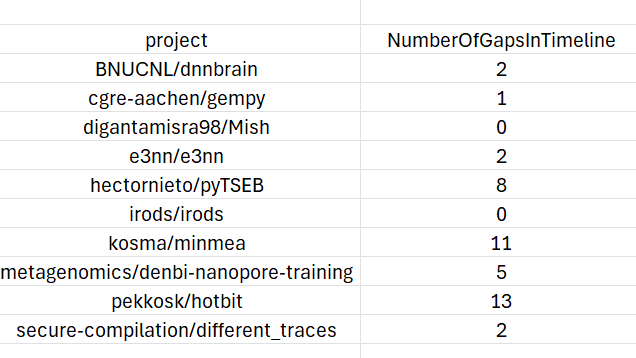